e# WESAD (LOSO) — PyTorch MLP

- ✅ **Oversample (WeightedRandomSampler) + Class Weights**
- ✅ **Rodar 5 seeds** e reportar **média ± desvio padrão**
- ✅ (Opcional) comparar **60/30 vs 30/15**

> CUDA é automático se existir.


## 0) Dependências (se necessário)
Se você já tem tudo instalado, pule esta célula.

In [1]:
# Se precisar, descomente e rode:
# !pip install -U numpy scipy scikit-learn matplotlib pandas torch

import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import f1_score, confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 1) Configurações

In [2]:
DATA_DIR = "/employee/ml/stress/dataset"
CLASSES = [1, 2, 3]
LABEL_NAMES = {1: "baseline", 2: "stress", 3: "amusement"}

# Recomendado: manter 60/30
WINDOW_STRIDE_GRID = [
    (60.0, 30.0),
    # (30.0, 15.0),  # descomente se quiser comparar
]

MAJORITY_THRESHOLD = 0.8
MIN_SAMPLES_PER_WINDOW = 8

ENABLE_PSD = True
ENABLE_HRV = True
SUBJECT_ZSCORE = True

# MLP
EPOCHS = 50
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 0.0
DROPOUT = 0.25

# Balanceamento
OVERSAMPLE = True
USE_CLASS_WEIGHTS = True

# Estabilidade
SEEDS = [42, 43, 44, 45, 46]

# Salvar modelos por fold (opcional)
SAVE_MODELS = True
OUT_DIR = "./artifacts_wesad_mlp_fixed"
os.makedirs(OUT_DIR, exist_ok=True)

print("OUT_DIR:", OUT_DIR)


OUT_DIR: ./artifacts_wesad_mlp_fixed


## 2) Funções: dados + features (igual base do seu script)

In [3]:
TARGET_FS_LABEL = 700.0

def find_subject_pkls(data_dir: str):
    pkls = sorted(glob.glob(os.path.join(data_dir, "S*", "S*.pkl")))
    if not pkls:
        raise FileNotFoundError(f"Nenhum S*.pkl encontrado em: {data_dir}")
    return pkls

def load_subject_pkl(path: str):
    with open(path, "rb") as f:
        return pickle.load(f, encoding="latin1")

def signal_slice(sig: np.ndarray, fs: float, t0: float, t1: float) -> np.ndarray:
    i0 = int(max(0, np.floor(t0 * fs)))
    i1 = int(max(0, np.floor(t1 * fs)))
    i1 = min(i1, sig.shape[0])
    if i1 <= i0:
        return np.empty((0,), dtype=float)
    arr = sig[i0:i1]
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr[:, 0]
    return arr

def robust_stats(x: np.ndarray):
    if x.size == 0:
        return [np.nan] * 10
    x = np.asarray(x, dtype=float)
    if not np.isfinite(x).any():
        return [np.nan] * 10
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    q25 = float(np.percentile(x, 25))
    q75 = float(np.percentile(x, 75))
    std = float(np.std(x))
    dx = np.diff(x)
    slope = float(np.mean(dx)) if dx.size else 0.0
    energy = float(np.mean(x * x))
    return [
        float(np.mean(x)),
        std,
        float(np.min(x)),
        float(np.max(x)),
        float(np.median(x)),
        q25,
        q75,
        float(q75 - q25),
        slope,
        energy,
    ]

def psd_bandpowers(x: np.ndarray, fs: float):
    if x.size < 8:
        return [np.nan] * 6
    x = np.asarray(x, dtype=float)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = x - np.mean(x)

    spec = np.abs(np.fft.rfft(x)) ** 2
    freqs = np.fft.rfftfreq(x.size, d=1.0 / fs)

    if spec.size <= 1:
        return [np.nan] * 6

    total = float(np.sum(spec))
    if total <= 0:
        return [0.0] * 6

    def band(a: float, b: float) -> float:
        mask = (freqs >= a) & (freqs < b)
        if not np.any(mask):
            return 0.0
        return float(np.sum(spec[mask]))

    p_lf = band(0.04, 0.15)
    p_mf = band(0.15, 0.40)
    p_hf = band(0.40, 1.00)

    idx = int(np.argmax(spec[1:]) + 1)
    peak_f = float(freqs[idx])
    centroid = float(np.sum(freqs * spec) / np.sum(spec))

    return [
        p_lf / total,
        p_mf / total,
        p_hf / total,
        (p_lf / (p_hf + 1e-12)),
        peak_f,
        centroid,
    ]

def hrv_from_bvp(bvp: np.ndarray, fs: float):
    if bvp.size < int(fs * 4):
        return [np.nan] * 7

    x = np.asarray(bvp, dtype=float)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)

    thr = float(np.percentile(x, 75))
    mid = x[1:-1]
    peak_mask = (mid > x[:-2]) & (mid >= x[2:]) & (mid > thr)
    peaks = np.where(peak_mask)[0] + 1

    if peaks.size < 3:
        return [np.nan] * 7

    min_dist = max(1, int(0.35 * fs))
    filtered = [int(peaks[0])]
    for p in peaks[1:]:
        if p - filtered[-1] >= min_dist:
            filtered.append(int(p))
        elif x[p] > x[filtered[-1]]:
            filtered[-1] = int(p)

    peaks = np.asarray(filtered, dtype=int)
    if peaks.size < 3:
        return [np.nan] * 7

    rr = np.diff(peaks) / fs
    rr = rr[(rr > 0.3) & (rr < 1.7)]
    if rr.size < 3:
        return [np.nan] * 7

    drr = np.diff(rr)
    sdnn = float(np.std(rr))
    rmssd = float(np.sqrt(np.mean(drr * drr))) if drr.size else np.nan
    pnn50 = float(np.mean(np.abs(drr) > 0.05)) if drr.size else np.nan
    hr = 60.0 / rr

    return [
        float(np.mean(rr)),
        sdnn,
        rmssd,
        pnn50,
        float(np.mean(hr)),
        float(np.std(hr)),
        float(rr.size),
    ]

def extract_window_features(wrist, t0, t1, enable_psd=True, enable_hrv=True):
    features = []
    specs = [
        ("ACC", 32.0),
        ("BVP", 64.0),
        ("EDA", 4.0),
        ("TEMP", 4.0),
    ]

    for name, fs in specs:
        sig = wrist[name]
        if name == "ACC":
            seg = signal_slice(sig, fs, t0, t1)
            if seg.ndim != 2 or seg.shape[1] != 3:
                features.extend([np.nan] * (10 * 4))
                if enable_psd:
                    features.extend([np.nan] * 6)
                continue
            for ax in range(3):
                features.extend(robust_stats(seg[:, ax]))
            mag = np.linalg.norm(seg, axis=1)
            features.extend(robust_stats(mag))
            if enable_psd:
                features.extend(psd_bandpowers(mag, fs))
        else:
            seg = signal_slice(sig, fs, t0, t1)
            features.extend(robust_stats(seg))
            if enable_psd:
                features.extend(psd_bandpowers(seg, fs))
            if enable_hrv and name == "BVP":
                features.extend(hrv_from_bvp(seg, fs))

    return np.asarray(features, dtype=float)

def window_majority_label(labels_700hz, t0, t1, allowed_labels, threshold=0.8):
    i0 = int(max(0, np.floor(t0 * TARGET_FS_LABEL)))
    i1 = int(min(labels_700hz.shape[0], np.floor(t1 * TARGET_FS_LABEL)))
    if i1 <= i0:
        return -1
    seg = labels_700hz[i0:i1].astype(int)
    seg = seg[np.isin(seg, allowed_labels)]
    if seg.size == 0:
        return -1
    c = Counter(seg.tolist())
    label, count = c.most_common(1)[0]
    purity = count / seg.size
    if purity < threshold:
        return -1
    return int(label)

@dataclass
class SubjectWindows:
    subject: str
    X: np.ndarray
    y: np.ndarray

def build_subject_windows(subj_pkl, allowed_labels, window_sec, stride_sec, majority_threshold,
                          min_samples_per_window, enable_psd=True, enable_hrv=True):
    obj = load_subject_pkl(subj_pkl)
    subject = os.path.splitext(os.path.basename(subj_pkl))[0]
    labels = np.asarray(obj["label"]).reshape(-1)
    wrist = obj["signal"]["wrist"]

    duration_sec = labels.shape[0] / TARGET_FS_LABEL
    windows_X, windows_y = [], []

    t = 0.0
    while t + window_sec <= duration_sec:
        t0, t1 = t, t + window_sec

        ok = True
        if signal_slice(wrist["EDA"], 4.0, t0, t1).shape[0] < min_samples_per_window: ok = False
        if signal_slice(wrist["TEMP"], 4.0, t0, t1).shape[0] < min_samples_per_window: ok = False
        if signal_slice(wrist["ACC"], 32.0, t0, t1).shape[0] < min_samples_per_window: ok = False
        if signal_slice(wrist["BVP"], 64.0, t0, t1).shape[0] < min_samples_per_window: ok = False

        if ok:
            y = window_majority_label(labels, t0, t1, allowed_labels, majority_threshold)
            if y != -1:
                feat = extract_window_features(
                    wrist, t0, t1,
                    enable_psd=enable_psd,
                    enable_hrv=enable_hrv
                )
                windows_X.append(feat)
                windows_y.append(y)

        t += stride_sec

    if windows_X:
        X = np.vstack(windows_X)
        y = np.asarray(windows_y, dtype=int)
    else:
        X = np.empty((0, 0), dtype=float)
        y = np.empty((0,), dtype=int)
    return SubjectWindows(subject, X, y)

def apply_subject_zscore(subject_data):
    out = []
    for s in subject_data:
        if s.X.size == 0:
            out.append(s)
            continue
        mu = np.nanmean(s.X, axis=0, keepdims=True)
        sd = np.nanstd(s.X, axis=0, keepdims=True)
        sd = np.where((sd < 1e-8) | ~np.isfinite(sd), 1.0, sd)
        Xn = (s.X - mu) / sd
        out.append(SubjectWindows(s.subject, Xn, s.y))
    return out


## 3) Construir janelas + visualizar distribuição

In [4]:
def build_all_subjects(window_sec, stride_sec):
    pkls = find_subject_pkls(DATA_DIR)
    subject_data = []
    for p in pkls:
        s = build_subject_windows(
            subj_pkl=p,
            allowed_labels=CLASSES,
            window_sec=window_sec,
            stride_sec=stride_sec,
            majority_threshold=MAJORITY_THRESHOLD,
            min_samples_per_window=MIN_SAMPLES_PER_WINDOW,
            enable_psd=ENABLE_PSD,
            enable_hrv=ENABLE_HRV,
        )
        subject_data.append(s)
    return pkls, subject_data

w0, st0 = WINDOW_STRIDE_GRID[0]
pkls, subject_data = build_all_subjects(w0, st0)

rows = []
for s in subject_data:
    cnt = Counter(s.y.tolist())
    rows.append({"subject": s.subject, "windows": len(s.y), **{LABEL_NAMES[k]: cnt.get(k, 0) for k in CLASSES}})

df_subj = pd.DataFrame(rows).sort_values("subject")
df_subj


/tmp/ipykernel_14467/364142385.py:11: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


,subject,windows,baseline,stress,amusement
0,S10,81,41,26,14
1,S11,82,42,25,15
2,S13,81,42,24,15
3,S14,80,41,24,15
4,S15,81,41,25,15
5,S16,79,41,24,14
6,S17,81,41,26,14
7,S2,77,40,23,14
8,S3,79,40,24,15
9,S4,78,41,23,14


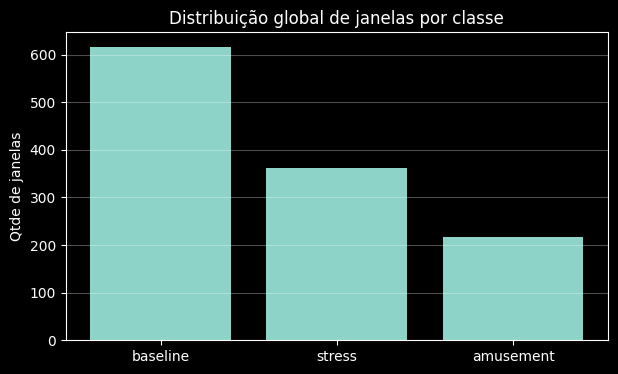

In [5]:
all_y = np.concatenate([s.y for s in subject_data if len(s.y) > 0])
counts = Counter(all_y.tolist())

plt.figure(figsize=(7,4))
plt.bar([LABEL_NAMES[c] for c in CLASSES], [counts.get(c, 0) for c in CLASSES])
plt.title("Distribuição global de janelas por classe")
plt.ylabel("Qtde de janelas")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


## 4) Modelo MLP + Treino (fixo)

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim: int, n_classes: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.net(x)

def make_loader(X, y, batch_size=64, oversample=False, seed=42):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)

    if not oversample:
        return DataLoader(ds, batch_size=batch_size, shuffle=True)

    classes, counts = np.unique(y, return_counts=True)
    w = {int(c): (1.0 / float(cnt)) for c, cnt in zip(classes, counts)}
    sample_weights = torch.tensor([w[int(label)] for label in y], dtype=torch.float32)

    sampler = WeightedRandomSampler(sample_weights, num_samples=len(y), replacement=True)
    return DataLoader(ds, batch_size=batch_size, sampler=sampler)

@torch.no_grad()
def predict(model, X, batch_size=256):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    preds = []
    for i in range(0, len(X_t), batch_size):
        logits = model(X_t[i:i+batch_size])
        preds.append(torch.argmax(logits, dim=1).cpu().numpy())
    return np.concatenate(preds)

def train_fixed_epochs(model, train_loader, *, lr=1e-3, weight_decay=1e-4, epochs=50, class_weights=None):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    if class_weights is not None:
        cw = torch.tensor(class_weights, dtype=torch.float32).to(device)
        crit = nn.CrossEntropyLoss(weight=cw)
    else:
        crit = nn.CrossEntropyLoss()

    history = []
    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        n = 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
            running += float(loss.item()) * xb.size(0)
            n += xb.size(0)
        history.append({"epoch": ep, "train_loss": running / max(1, n)})
    return history


## 5) LOSO + 5 seeds + salvar modelos

In [7]:
def loso_mlp_fixed(subject_data, *, seed: int, window_sec: float, stride_sec: float):
    sd = apply_subject_zscore(subject_data) if SUBJECT_ZSCORE else subject_data
    valid = [s for s in sd if s.X.size > 0]

    cls_sorted = list(CLASSES)
    to_idx = {c:i for i,c in enumerate(cls_sorted)}
    to_lbl = {i:c for i,c in enumerate(cls_sorted)}

    fold_rows = []
    all_true, all_pred = [], []
    model_dir = os.path.join(OUT_DIR, f"w{int(window_sec)}s{int(stride_sec)}", f"seed_{seed}")
    if SAVE_MODELS:
        os.makedirs(model_dir, exist_ok=True)

    for i, test_subj in enumerate(valid):
        train_subjs = [s for s in valid if s.subject != test_subj.subject]

        X_train = np.vstack([s.X for s in train_subjs])
        y_train = np.concatenate([s.y for s in train_subjs])
        X_test  = test_subj.X
        y_test  = test_subj.y

        y_train_i = np.array([to_idx[int(y)] for y in y_train], dtype=int)
        y_test_i  = np.array([to_idx[int(y)] for y in y_test], dtype=int)

        class_weights = None
        if USE_CLASS_WEIGHTS:
            counts = np.bincount(y_train_i, minlength=len(cls_sorted)).astype(float)
            class_weights = (counts.sum() / (counts + 1e-9))
            class_weights = class_weights / class_weights.mean()

        train_loader = make_loader(
            X_train, y_train_i,
            batch_size=BATCH_SIZE,
            oversample=OVERSAMPLE,
            seed=seed+i
        )

        model = MLP(in_dim=X_train.shape[1], n_classes=len(cls_sorted), dropout=DROPOUT)

        train_fixed_epochs(
            model, train_loader,
            lr=LR, weight_decay=WEIGHT_DECAY,
            epochs=EPOCHS,
            class_weights=class_weights
        )

        y_pred_i = predict(model, X_test)
        fold_macro = f1_score(y_test_i, y_pred_i, average="macro")

        y_pred_lbl = np.array([to_lbl[int(k)] for k in y_pred_i], dtype=int)

        fold_rows.append({"subject": test_subj.subject, "windows": len(y_test), "macro_f1": fold_macro})
        all_true.extend(y_test.tolist())
        all_pred.extend(y_pred_lbl.tolist())

        if SAVE_MODELS:
            torch.save({
                "state_dict": model.state_dict(),
                "in_dim": int(X_train.shape[1]),
                "classes": cls_sorted,
                "label_names": LABEL_NAMES,
                "window_sec": window_sec,
                "stride_sec": stride_sec,
                "seed": seed,
                "subject_test": test_subj.subject,
            }, os.path.join(model_dir, f"mlp_fold_test_{test_subj.subject}.pt"))

        print(f"[LOSO][Fixed] seed={seed} test={test_subj.subject:>4} macro_f1={fold_macro:.4f}")

    y_true = np.array(all_true, dtype=int)
    y_hat  = np.array(all_pred, dtype=int)

    macro = f1_score(y_true, y_hat, average="macro")
    cm = confusion_matrix(y_true, y_hat, labels=cls_sorted)
    rep = classification_report(y_true, y_hat, labels=cls_sorted, digits=4, output_dict=True)

    return pd.DataFrame(fold_rows).sort_values("subject"), macro, cm, rep

def run_all():
    all_runs = []
    details = {}

    for (w, st) in WINDOW_STRIDE_GRID:
        _, sd = build_all_subjects(w, st)

        for seed in SEEDS:
            fold_df, macro, cm, rep = loso_mlp_fixed(sd, seed=seed, window_sec=w, stride_sec=st)

            all_runs.append({
                "window_sec": w,
                "stride_sec": st,
                "seed": seed,
                "macro_f1": macro,
                "accuracy": rep["accuracy"],
                "f1_baseline": rep["1"]["f1-score"],
                "f1_stress": rep["2"]["f1-score"],
                "f1_amusement": rep["3"]["f1-score"],
            })
            details[(w, st, seed)] = {"fold_df": fold_df, "cm": cm, "rep": rep}

    return pd.DataFrame(all_runs), details

df_runs, details = run_all()
df_runs


/tmp/ipykernel_14467/364142385.py:11: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


[LOSO][Fixed] seed=42 test= S10 macro_f1=0.5880
[LOSO][Fixed] seed=42 test= S11 macro_f1=0.7813
[LOSO][Fixed] seed=42 test= S13 macro_f1=0.6022
[LOSO][Fixed] seed=42 test= S14 macro_f1=0.7246
[LOSO][Fixed] seed=42 test= S15 macro_f1=0.6053
[LOSO][Fixed] seed=42 test= S16 macro_f1=0.6901
[LOSO][Fixed] seed=42 test= S17 macro_f1=0.4349
[LOSO][Fixed] seed=42 test=  S2 macro_f1=0.8577
[LOSO][Fixed] seed=42 test=  S3 macro_f1=0.6977
[LOSO][Fixed] seed=42 test=  S4 macro_f1=0.6099
[LOSO][Fixed] seed=42 test=  S5 macro_f1=0.8067
[LOSO][Fixed] seed=42 test=  S6 macro_f1=0.9250
[LOSO][Fixed] seed=42 test=  S7 macro_f1=0.8589
[LOSO][Fixed] seed=42 test=  S8 macro_f1=0.7667
[LOSO][Fixed] seed=42 test=  S9 macro_f1=0.9540
[LOSO][Fixed] seed=43 test= S10 macro_f1=0.5736
[LOSO][Fixed] seed=43 test= S11 macro_f1=0.8895
[LOSO][Fixed] seed=43 test= S13 macro_f1=0.6889
[LOSO][Fixed] seed=43 test= S14 macro_f1=0.6087
[LOSO][Fixed] seed=43 test= S15 macro_f1=0.5957
[LOSO][Fixed] seed=43 test= S16 macro_f1

,window_sec,stride_sec,seed,macro_f1,accuracy,f1_baseline,f1_stress,f1_amusement
0,60.0,30.0,42,0.742279,0.780570,0.806426,0.889518,0.530892
1,60.0,30.0,43,0.736190,0.776382,0.810373,0.892704,0.505495
2,60.0,30.0,44,0.751440,0.793132,0.824281,0.892655,0.537383
3,60.0,30.0,45,0.729303,0.776382,0.810510,0.884507,0.492891
4,60.0,30.0,46,0.739391,0.777219,0.807818,0.875524,0.534831


## 6) Summary (média ± desvio) + gráficos

In [8]:
summary = (
    df_runs
    .groupby(["window_sec", "stride_sec"])
    .agg(
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        f1_amusement_mean=("f1_amusement", "mean"),
        f1_amusement_std=("f1_amusement", "std"),
        f1_stress_mean=("f1_stress", "mean"),
        f1_stress_std=("f1_stress", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
    )
    .reset_index()
    .sort_values("macro_f1_mean", ascending=False)
)
summary


,window_sec,stride_sec,macro_f1_mean,macro_f1_std,f1_amusement_mean,f1_amusement_std,f1_stress_mean,f1_stress_std,accuracy_mean,accuracy_std
0,60.0,30.0,0.739721,0.008139,0.520299,0.01991,0.886982,0.007224,0.780737,0.007141


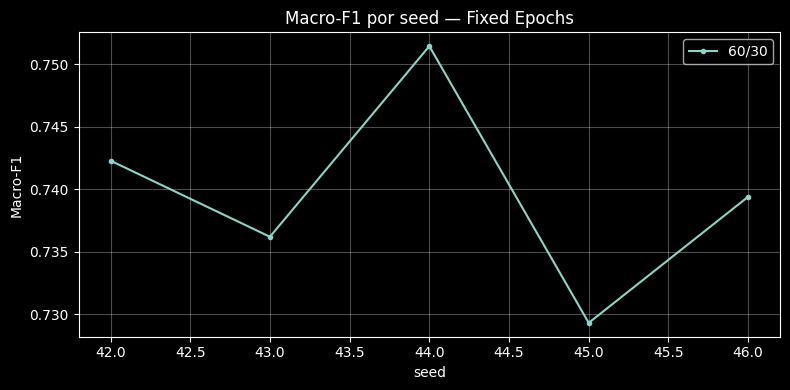

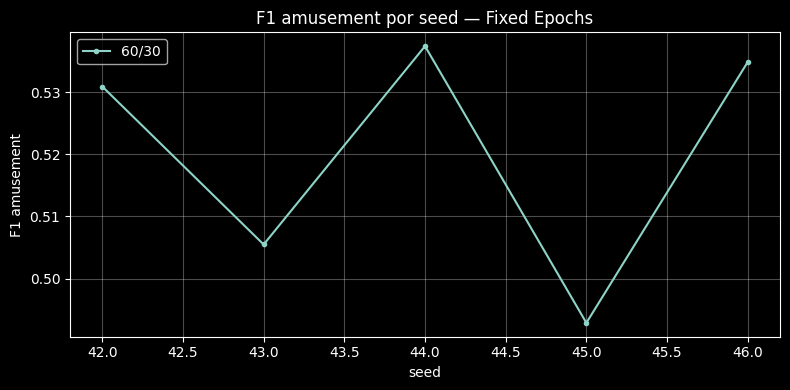

In [9]:
plt.figure(figsize=(8,4))
for (w, st), g in df_runs.groupby(["window_sec", "stride_sec"]):
    g2 = g.sort_values("seed")
    plt.plot(g2["seed"], g2["macro_f1"], marker=".", label=f"{int(w)}/{int(st)}")
plt.title("Macro-F1 por seed — Fixed Epochs")
plt.xlabel("seed")
plt.ylabel("Macro-F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
for (w, st), g in df_runs.groupby(["window_sec", "stride_sec"]):
    g2 = g.sort_values("seed")
    plt.plot(g2["seed"], g2["f1_amusement"], marker=".", label=f"{int(w)}/{int(st)}")
plt.title("F1 amusement por seed — Fixed Epochs")
plt.xlabel("seed")
plt.ylabel("F1 amusement")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
